In [ ]:
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
import numpy as np
import torch

In [ ]:
seed = 12239

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

In [ ]:
class ClientDataset(Dataset):
    def __init__(self, df):
        # Ensure all features are numeric
        for col in df.columns:
            if col != "label_encoded":
                df[col] = pd.to_numeric(df[col], errors="coerce")
        df = df.fillna(0)

        self.X = torch.tensor(df.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
        self.y = torch.tensor(df["label_encoded"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # match Notebook 2 architecture
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)  # output logits

    def forward(self, x):
        x = torch.relu(self.fc1(x))   # hidden layer activation
        x = torch.relu(self.fc2(x))   # hidden layer activation
        x = self.fc3(x)               # output logits (no sigmoid here)
        return x

### Run this for IID

In [ ]:
num_clients = 10
client_dfs = []

for i in range(1, num_clients + 1):
    df_client = pd.read_csv(f"client{i}-IID.csv")
    df_client = df_client.sample(frac=1, random_state=42).reset_index(drop=True)  # optional shuffle
    client_dfs.append(df_client)

print(f"Loaded {num_clients} client datasets successfully.")

Loaded 10 client datasets successfully.


### Run this for nonIID

In [ ]:
num_clients = 10
client_dfs = []

for i in range(1, num_clients + 1):
    df_client = pd.read_csv(f"client-{i}-nonIID.csv")
    df_client = df_client.sample(frac=1, random_state=42).reset_index(drop=True)  # optional shuffle (deterministic)
    client_dfs.append(df_client)

print(f"Loaded {num_clients} client datasets successfully.")

Loaded 10 client datasets successfully.


### Training Rounds and other variables

In [ ]:
num_rounds = 20
batch_size = 320
lr = 0.0001
local_epochs = 1

clip_norm = 1.0

input_dim = client_dfs[0].drop(["label", "label_encoded"], axis=1).shape[1]

all_labels = pd.concat(client_dfs)["label_encoded"]
pos = (all_labels == 1).sum()
neg = (all_labels == 0).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)

global_model = MLP(input_dim)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Global model initialized with pos_weight={pos_weight.item():.4f}")

Global model initialized with pos_weight=0.0300


In [ ]:
def clip_update(update_state_dict, C):
    total_norm = 0.0
    for key in update_state_dict:
        total_norm = total_norm + torch.norm(update_state_dict[key])**2
    total_norm = torch.sqrt(total_norm)

    clip_factor = min(1.0, C / (total_norm + 1e-6))
    for key in update_state_dict:
        update_state_dict[key] = update_state_dict[key] * clip_factor

    return update_state_dict

### Training

In [ ]:
for r in range(num_rounds):
    print(f"\n=== FL Round {r+1} ===")
    client_updates = []

    for i, client_df in enumerate(client_dfs):
        # Prepare dataset and dataloader with deterministic seeds (match Notebook 2)
        client_dataset = ClientDataset(client_df)
        loader = DataLoader(
            client_dataset,
            batch_size=batch_size,
            shuffle=True,
            worker_init_fn=lambda worker_id: np.random.seed(42 + worker_id),
            generator=torch.Generator().manual_seed(42)
        )

        # Initialize client model with global weights
        client_model = MLP(input_dim)
        client_model.load_state_dict(global_model.state_dict())
        optimizer = optim.Adam(client_model.parameters(), lr=lr)

        # Local training
        client_model.train()
        for epoch in range(local_epochs):
            for X, y in loader:
                optimizer.zero_grad()
                preds = client_model(X)
                loss = loss_fn(preds, y)
                loss.backward()
                optimizer.step()

        # Build the update = client_weights - global_weights
        update = {}
        for key in global_model.state_dict().keys():
            update[key] = client_model.state_dict()[key] - global_model.state_dict()[key]

        # Clip update (matching Notebook 2's clipping behavior; no noise added)
        update = clip_update(update, clip_norm)

        # Append the clipped update for aggregation
        client_updates.append(update)

        print(f"Client {i+1} trained, last batch loss: {loss.item():.4f}")

    # If no active updates (shouldn't happen here) break
    if len(client_updates) == 0:
        print("No client updates; stopping.")
        break

    # Aggregate: additive FedAvg style used in Notebook 2
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        stacked = torch.stack([upd[key] for upd in client_updates], dim=0)
        # apply mean of updates to global (global += mean(update))
        global_dict[key] = global_dict[key] + stacked.mean(0)
    global_model.load_state_dict(global_dict)
    print("Global model updated.")

    # Evaluate global model on concatenated client data
    global_model.eval()
    df_full = pd.concat(client_dfs).reset_index(drop=True)

    for col in df_full.columns:
        if col != "label_encoded":
            df_full[col] = pd.to_numeric(df_full[col], errors="coerce")
    df_full = df_full.fillna(0)

    X_global = torch.tensor(df_full.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
    y_global = torch.tensor(df_full["label_encoded"].values, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        logits_global = global_model(X_global)
        probs = torch.sigmoid(logits_global)
        preds = (probs > 0.5).float()

    accuracy = accuracy_score(y_global.numpy(), preds.numpy())
    print(f"Global model accuracy after round {r+1}: {accuracy:.4f}")


=== FL Round 1 ===
Client 1 trained, last batch loss: 0.0001
Client 2 trained, last batch loss: 0.0000
Client 3 trained, last batch loss: 0.0000
Client 4 trained, last batch loss: 0.0000
Client 5 trained, last batch loss: 0.0000
Client 6 trained, last batch loss: 0.0000
Client 7 trained, last batch loss: 0.0000
Client 8 trained, last batch loss: 0.0000
Client 9 trained, last batch loss: 0.0000
Client 10 trained, last batch loss: 0.0000
Global model updated.
Global model accuracy after round 1: 0.9999

=== FL Round 2 ===
Client 1 trained, last batch loss: 0.0001
Client 2 trained, last batch loss: 0.0000
Client 3 trained, last batch loss: 0.0000
Client 4 trained, last batch loss: 0.0000
Client 5 trained, last batch loss: 0.0000
Client 6 trained, last batch loss: 0.0000
Client 7 trained, last batch loss: 0.0000
Client 8 trained, last batch loss: 0.0000
Client 9 trained, last batch loss: 0.0000
Client 10 trained, last batch loss: 0.0000
Global model updated.
Global model accuracy after ro

### Evaluation

#### Load test dataset




In [ ]:
test_path = "scen-testing.csv"
print(f"\nLoading external test file: {test_path}")

df_test = pd.read_csv(test_path)

# Ensure numeric conversion (same preprocessing as training)
for col in df_test.columns:
    if col != "label_encoded":
        df_test[col] = pd.to_numeric(df_test[col], errors="coerce")

df_test = df_test.fillna(0)
df_test = df_test.dropna(subset=["label_encoded"])  # ensure valid labels



Loading external test file: scen-testing.csv


#### Evaluate

In [ ]:
global_model.eval()

# --- Prepare test tensors ---
X_test = torch.tensor(df_test.drop(["label", "label_encoded"], axis=1).values, dtype=torch.float32)
y_test = torch.tensor(df_test["label_encoded"].values, dtype=torch.float32).unsqueeze(1)

# --- Run model inference ---
with torch.no_grad():
    logits = global_model(X_test)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

y_true = y_test.numpy()
y_pred = preds.numpy()

# --- Evaluation metrics ---
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("\n=== Evaluation on scen-testing.csv ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("Confusion Matrix:")
print(cm)



=== Evaluation on scen-testing.csv ===
Accuracy:  0.9999
Precision: 1.0000
Recall:    0.9999
F1-score:  1.0000
Confusion Matrix:
[[ 17049      1]
 [    35 569024]]


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, probs.numpy())
print(f"AUC: {auc:.4f}")

AUC: 1.0000


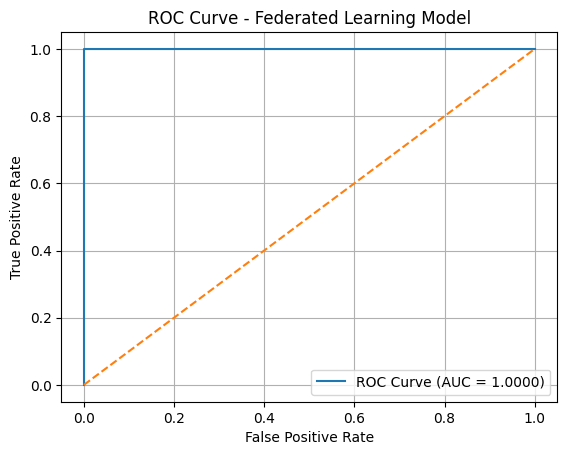

AUC: 1.0000


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_true, probs.numpy())

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # Random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Federated Learning Model")
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.4f}")